# NIVARIA Gasifier — Step 3: Validation with N₂ Flow (Empty Column)

**Objective**: verify that the heater powers identified in Steps 1 and 2 correctly predict
the wall temperature evolution when N₂ is actively injected into the empty column.

| Power set | Source case | File |
|-----------|-------------|------|
| **Set A** | Case idx=2 (Step 1) | `step1_heater_powers.json` |
| **Set B** | Case idx=3 (Step 2) | `step2_case3_heater_powers.json` |

**Validation cases** (empty column, no biomass, N₂ flow):
- **idx=8** — `20260212_NIVARIA_prueba_15 cribado`
- **idx=13** — `20260317_NIVARIA_prueba_20 sin cribar_3aRemesa`
- **idx=14** — `20260319_NIVARIA_prueba_15 sin cribar_3aRemesa`

## Key differences from Steps 1 and 2

- `v_in > 0`: N₂ superficial inlet velocity derived from the flow-meter reading
- `T_in` from the measured inlet gas temperature sensor
- Convective transport along the column is no longer negligible
- The simulation uses the **same heater powers** — no re-fitting

## Flow averaging assumption

The measured N₂ flow rate varies over time (meter fluctuations, ramp-up transients).
The simulator uses a **single constant v_in** equal to the time-mean of the measured flow:

$$v_{in} = \frac{\overline{Q}_{N_2}^{actual}}{A_i}$$

where $\overline{Q}^{actual}$ is the mean volumetric flow corrected from normal to actual
conditions via the ideal-gas law:

$$Q^{actual} = \overline{Q}^{normal} \cdot \frac{T_{in}}{T_0} \cdot \frac{P_0}{P}$$

The exploratory plot in Section 7 shows the measured flow profile together with this mean value
so that the user can assess how representative the approximation is for each case.

## 1. Imports and configuration

In [1]:
import os, sys, json, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ── Paths ─────────────────────────────────────────────────────────────────────
ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
EXP  = os.getcwd()

for p in [ROOT, EXP]:
    if p not in sys.path:
        sys.path.insert(0, p)

# ── HEATER API ────────────────────────────────────────────────────────────────
from src.units.heater.config.gas_props  import build_gas_prop_config
from src.units.heater.config.boundary_c import build_boundary_c_config
from src.units.heater.config.thermal_bc import build_thermal_bc_config
from src.units.heater.config.transport  import build_transport_config
from src.units.heater.config.initial_c  import build_initial_c_config
from src.units.heater.config.wall_c     import build_wall_config
from src.units.heater.state             import pack_state_vector
from src.solvers.runner_heater          import run_step

# ── Experimental data ─────────────────────────────────────────────────────────
from getDataHeater import (
    process_folder_for_empty_validation,
    build_empty_segments_for_cases,
    build_empty_segments_summary,
)

DB_GAS   = os.path.join(ROOT, "materials", "fluids",  "gasdb.txt")
DB_SOLID = os.path.join(ROOT, "materials", "solids", "soliddb.txt")
RAW_DIR  = os.path.join(EXP, "rawData")
RES_DIR  = os.path.join(EXP, "results")

print("Imports OK")

Imports OK


## 2. Load identified heater power sets

In [2]:
def _load_powers(fname):
    path = os.path.join(RES_DIR, fname)
    if not os.path.isfile(path):
        raise FileNotFoundError(f"Power file not found: {path}")
    with open(path) as f:
        return json.load(f)

step1 = _load_powers("step1_heater_powers.json")
step2 = _load_powers("step2_case3_heater_powers.json")

POWER_SETS = {
    "Set A (case 2)": {
        "Q_b": float(step1["Q_bottom_W"]),
        "Q_m": float(step1["Q_middle_W"]),
        "Q_t": float(step1["Q_top_W"]),
    },
    "Set B (case 3)": {
        "Q_b": float(step2["Q_bottom_W"]),
        "Q_m": float(step2["Q_middle_W"]),
        "Q_t": float(step2["Q_top_W"]),
    },
}

print(f"  {'Power set':20s}  {'Q_bottom':>10}  {'Q_middle':>10}  {'Q_top':>10}  {'Q_total':>10}")
print(f"  {'-'*20}  {'-'*10}  {'-'*10}  {'-'*10}  {'-'*10}")
for name, ps in POWER_SETS.items():
    print(f"  {name:20s}  {ps['Q_b']:>10.1f}  {ps['Q_m']:>10.1f}  {ps['Q_t']:>10.1f}  {ps['Q_b']+ps['Q_m']+ps['Q_t']:>10.1f}")

  Power set               Q_bottom    Q_middle       Q_top     Q_total
  --------------------  ----------  ----------  ----------  ----------
  Set A (case 2)             206.7       130.3       165.6       502.6
  Set B (case 3)             202.2       136.3       169.3       507.8


## 3. Load experimental data

In [3]:
cases_raw = process_folder_for_empty_validation(RAW_DIR, min_pre_feed_min=5.0)
cases_seg = build_empty_segments_for_cases(cases_raw)
summary   = build_empty_segments_summary(cases_seg)

VAL_INDICES = [8, 13, 14]

print("Validation cases:")
print(summary.loc[summary["idx"].isin(VAL_INDICES)].to_string(index=False))

Validation cases:
 idx                                            file_name  ok_read  ok_empty_validation  ok_empty_segment                                reason t_start_h  t_end_h  duration_min  n_process  n_avgT
   8             20260212_NIVARIA_prueba_ 15 cribado.xlsx     True                 True              True Tramo vacío construido correctamente.  09:53:52 11:16:00     82.133333        206     206
  13 20260317_NIVARIA_prueba_ 20 sin cribar_3aRemesa.xlsx     True                 True              True Tramo vacío construido correctamente.  09:51:09 11:05:00     73.850000        185     185
  14 20260319_NIVARIA_prueba_ 15 sin cribar_3aRemesa.xlsx     True                 True              True Tramo vacío construido correctamente.  11:55:38 13:00:00     64.366667        161     161


## 4. Inspect available data segments and columns

Check which segment keys and column names are present for cases 8, 13, 14.

In [4]:
for idx in VAL_INDICES:
    case = cases_seg[idx]
    print(f"\n[{idx}] {case['file_name']}")
    df_pe = case["dfs"].get("process_empty")
    if df_pe is not None and len(df_pe) > 0:
        print(f"  [process_empty]  shape={df_pe.shape}")
        print(f"  columns: {list(df_pe.columns)}")


[8] 20260212_NIVARIA_prueba_ 15 cribado.xlsx
  [process_empty]  shape=(206, 23)
  columns: ['Hora', 'Temp_aire-Ten_QS_0', 'Temp_aire-Ten_TA_1', 'Temp_aire-Ten_TA_2', 'Temp_aire-Ten_TG_2', 'Temp_aire-Ten_TG_1', 'Temp_aire-Ten_TG_3', 'Temp_aire-Ten_TG_4', 'Temp_aire-Ten_TG_9', 'Temp_aire-Ten_TW_2', 'Temp_aire-Ten_TW_4', 'Temp_aire-Ten_PA_0', 'Temp_aire-Ten_PG_5', 'Temp_aire-Ten_PG_8', 'Temp_aire-Ten_PG_2_PG_3', 'Temp_aire-Ten_PG_3_PG_5', 'Temp_aire-Ten_QA_0', 'Temp_aire-Ten_PA_1_PG_1', 'Temp_aire-Ten_QS_0__2', 'clock_s', 'Hora_str', 'datetime', 'x_min']

[13] 20260317_NIVARIA_prueba_ 20 sin cribar_3aRemesa.xlsx
  [process_empty]  shape=(185, 23)
  columns: ['Hora', 'Temp_aire-Ten_QS_0', 'Temp_aire-Ten_TA_1', 'Temp_aire-Ten_TA_2', 'Temp_aire-Ten_TG_2', 'Temp_aire-Ten_TG_1', 'Temp_aire-Ten_TG_3', 'Temp_aire-Ten_TG_4', 'Temp_aire-Ten_TG_9', 'Temp_aire-Ten_TW_2', 'Temp_aire-Ten_TW_4', 'Temp_aire-Ten_PA_0', 'Temp_aire-Ten_PG_5', 'Temp_aire-Ten_PG_8', 'Temp_aire-Ten_PG_2_PG_3', 'Temp_aire-Ten

## 5. Gasifier geometry and flow conversion

Update `SEGMENT_KEY`, `FLOW_COL`, `FLOW_UNIT`, `T_IN_COL` and `T_WALL_COLS`
based on the inspection above before running the simulation cells.

In [5]:
# ── Gasifier geometry (identical to steps 1 & 2) ───────────────────────────
L   = 0.75
Di  = 0.08
Do  = 0.09
N   = 3

e_wall = (Do - Di) / 2.0
dz     = L / N
Ai     = 0.25 * np.pi * Di**2   # cross-sectional area [m²]
Pi     = np.pi * Di
Po     = np.pi * Do

nc      = 1
SPECIES = ["N2"]
RTOL    = 1.0e-6
ATOL    = 1.0e-8
N_SEC   = 20
P_INIT  = 1.01325   # bar

# ── Data extraction settings ───────────────────────────────────────────────
# Temperatures (TG_1/2/3, T_in) live in process_empty.
# Flow lives in avgT_empty ("Caudal aire").  QS_0 in process_empty is all-NaN.

SEGMENT_KEY      = "process_empty"   # temperature data (has x_min)
FLOW_SEGMENT_KEY = "avgT_empty"      # flow data (has x_min)

FLOW_COL  = "Caudal aire"            # flow column in avgT_empty (Nl/min)
FLOW_UNIT = "Nl/min"                 # "Nl/min", "L/min", "Nm3/h"

T_IN_COL  = "Temp_aire-Ten_TA_1"     # inlet air temperature in process_empty (°C)

T_WALL_COLS = {
    "TG_1": "Temp_aire-Ten_TG_1",
    "TG_2": "Temp_aire-Ten_TG_2",
    "TG_3": "Temp_aire-Ten_TG_3",
}

# Normal conditions for volumetric → actual flow conversion
T_NORM_K = 273.15    # K
P_NORM   = 101325.0  # Pa


def flow_to_velocity(Q_col: np.ndarray, T_gas_K: float, P_Pa: float) -> tuple:
    """
    Convert a flow-meter time series to a single constant superficial velocity [m/s].

    The flow varies in time; we average the entire segment to a constant value.
    Ideal-gas correction from normal to actual (T, P) conditions.

    Returns
    -------
    v_in_ms : float   — mean superficial velocity [m/s]
    Q_mean  : float   — mean flow in original units (for display)
    Q_std   : float   — std of flow in original units (measure of variability)
    """
    finite = Q_col[np.isfinite(Q_col)]
    if finite.size == 0:
        raise ValueError(f"Flow column '{FLOW_COL}' contains no finite values in segment '{FLOW_SEGMENT_KEY}'.")
    Q_mean = float(np.mean(finite))
    Q_std  = float(np.std(finite))

    if FLOW_UNIT == "Nl/min":
        Q_norm_m3s = Q_mean * 1e-3 / 60.0
    elif FLOW_UNIT == "L/min":
        Q_norm_m3s = Q_mean * 1e-3 / 60.0
    elif FLOW_UNIT == "Nm3/h":
        Q_norm_m3s = Q_mean / 3600.0
    else:
        raise ValueError(f"Unknown FLOW_UNIT: {FLOW_UNIT}")

    Q_actual_m3s = Q_norm_m3s * (T_gas_K / T_NORM_K) * (P_NORM / P_Pa)
    return Q_actual_m3s / Ai, Q_mean, Q_std


def _first_finite(arr, n=5):
    finite = arr[np.isfinite(arr)]
    if finite.size == 0:
        raise ValueError("Array contains no finite values.")
    return float(np.mean(finite[:n]))


print(f"Ai = {Ai*1e4:.4f} cm²")
print(f"SEGMENT_KEY      = '{SEGMENT_KEY}'   (temperatures)")
print(f"FLOW_SEGMENT_KEY = '{FLOW_SEGMENT_KEY}'    (flow)")
print(f"FLOW_COL         = '{FLOW_COL}'  [{FLOW_UNIT}]")
print(f"T_IN_COL         = '{T_IN_COL}'")

Ai = 50.2655 cm²
SEGMENT_KEY      = 'process_empty'   (temperatures)
FLOW_SEGMENT_KEY = 'avgT_empty'    (flow)
FLOW_COL         = 'Caudal aire'  [Nl/min]
T_IN_COL         = 'Temp_aire-Ten_TA_1'


## 6. Simulation function

In [6]:
def simulate_n2flow(case, Q_bottom, Q_middle, Q_top):
    """
    Simulate the empty-column N2-flow phase for a given case.

    Temperatures (TG_1/2/3, T_in) read from SEGMENT_KEY (process_empty).
    Flow read from FLOW_SEGMENT_KEY (avgT_empty), column FLOW_COL.
    v_in is the time-mean of the measured flow, corrected to actual conditions.
    T_in is the time-mean of the measured inlet temperature (TA_1).

    Returns
    -------
    t_exp_s, T_exp_K, T_in_exp_K, v_in_ms, t_sim, h, cpu_s
    """
    df      = case["dfs"][SEGMENT_KEY].copy()
    df_flow = case["dfs"][FLOW_SEGMENT_KEY].copy()

    t_exp_s = df["x_min"].values * 60.0
    T_exp_K = {
        lbl: pd.to_numeric(df[col], errors="coerce").values + 273.15
        for lbl, col in T_WALL_COLS.items()
    }
    T_MAX_s = float(t_exp_s[-1])

    # Inlet gas temperature: time-mean from process_empty [K]
    T_in_arr   = pd.to_numeric(df[T_IN_COL], errors="coerce").values + 273.15
    T_in_exp_K = T_in_arr
    T_in_mean  = float(np.nanmean(T_in_arr[np.isfinite(T_in_arr)]))

    # Inlet velocity: time-mean of flow from avgT_empty → constant v_in
    Q_arr = pd.to_numeric(df_flow[FLOW_COL], errors="coerce").values
    v_in_ms, Q_mean, Q_std = flow_to_velocity(Q_arr, T_in_mean, P_INIT * 1e5)

    # Initial wall temperature from first finite sensor samples
    Tw_init = np.array([
        _first_finite(T_exp_K["TG_1"]),
        _first_finite(T_exp_K["TG_2"]),
        _first_finite(T_exp_K["TG_3"]),
    ])
    T_gas_init = float(np.mean(Tw_init))

    print(f"  Flow: mean={Q_mean:.2f} ± {Q_std:.2f} {FLOW_UNIT}  →  v_in={v_in_ms*100:.3f} cm/s  "
          f"(CV={Q_std/max(Q_mean,1e-9)*100:.1f} %)")
    print(f"  T_in mean: {T_in_mean:.1f} K ({T_in_mean-273.15:.1f} °C)")
    print(f"  Tw_init [K]: {Tw_init.round(1)}")

    prop_gas  = build_gas_prop_config(
        species=SPECIES, mode="polynomial", n_comp=nc, N=N, db_path=DB_GAS,
    )
    gas_T_ref = float(np.min(np.asarray(prop_gas["Tref"])))

    bc  = build_boundary_c_config(
        n_comp=nc, v_in=v_in_ms, T_in=T_in_mean,
        y_in=np.array([1.0]), P_out=P_INIT,
    )
    tbc = build_thermal_bc_config(
        mode="heatfluxwall", Di=Di, Do=Do, e_wall=e_wall,
        Qwall=np.array([Q_bottom, Q_middle, Q_top], dtype=float),
    )
    tc  = build_transport_config(mode="correlation", N=N)
    wc  = build_wall_config(
        N=N, Di=Di, Do=Do, T_w_init=Tw_init,
        material_id="SS316L", material_mode="polynomial", db_path=DB_SOLID,
    )
    ic  = build_initial_c_config(
        P_init=P_INIT, Tg_init=T_gas_init, y_init=np.array([1.0]),
        n_comp=nc, N=N, prop_gas=prop_gas, gas_T_ref=gas_T_ref,
        wall_config=wc,
    )
    sv0 = pack_state_vector(ic["C_init"], ic["Hg_init"], Tw=ic["Tw_init"])

    params = {
        "n_comp": nc, "N": N, "dz": dz, "Ai": Ai, "Di": Di, "Pi": Pi, "Po": Po,
        "prop_gas": prop_gas, "MW": np.asarray(prop_gas["MW"]),
        "gas_T_ref": gas_T_ref,
        "bc_config": bc, "trans_config": tc, "thermal_bc_config": tbc,
        "energy": True, "prop_update_mode": "always", "trans_update_mode": "always",
        "species": SPECIES, "wall_config": wc, "_cache": {},
    }

    t0 = time.perf_counter()
    t_sim, _, h = run_step(
        sv0=sv0, t_max=T_MAX_s, params=params,
        solver="solve_ivp", rtol=RTOL, atol=ATOL, n_sec=N_SEC,
    )
    cpu_s = time.perf_counter() - t0

    return t_exp_s, T_exp_K, T_in_exp_K, v_in_ms, t_sim, h, cpu_s


print("simulate_n2flow defined OK")

simulate_n2flow defined OK


## 7. Flow and temperature profiles — exploratory check

Plot the measured flow rate and temperatures for each validation case before running the simulation,
to confirm the segment is correct and the flow is reasonably steady.

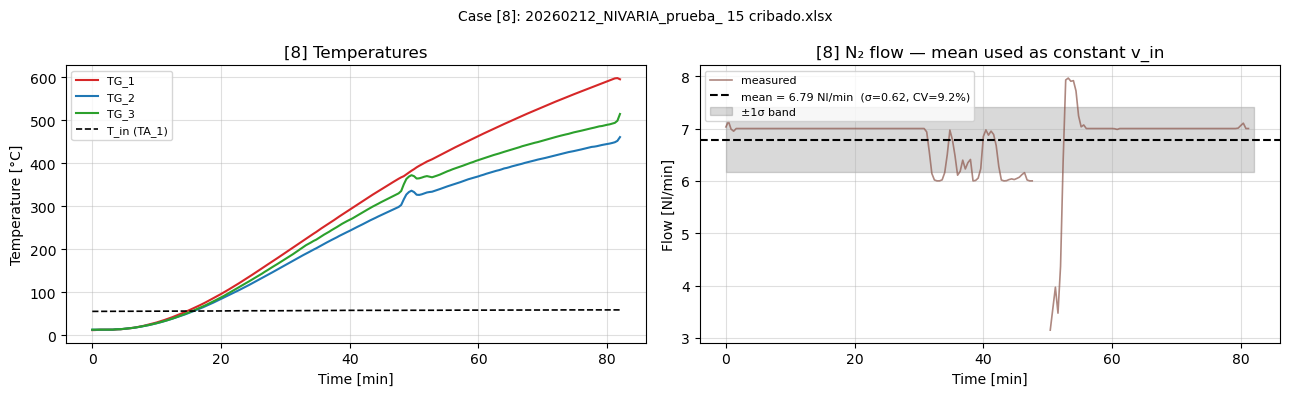

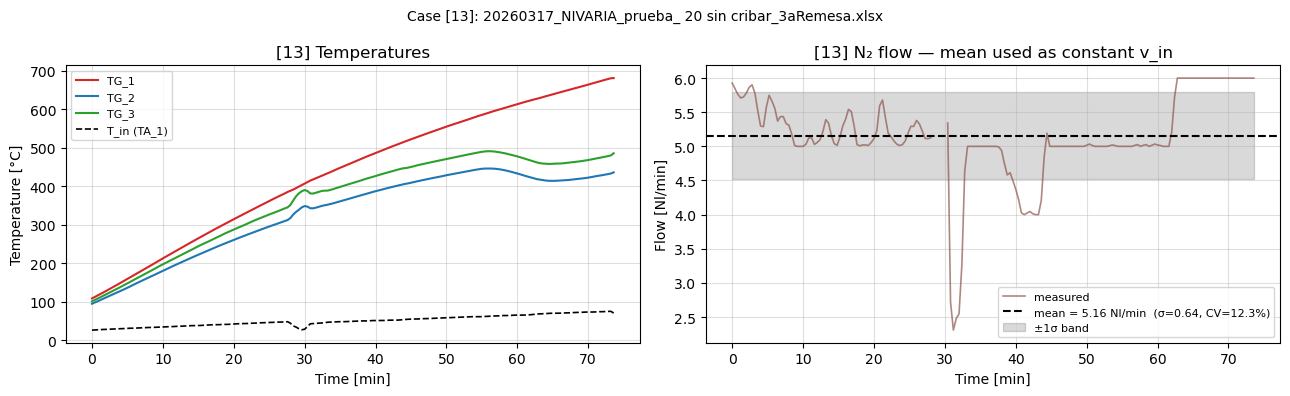

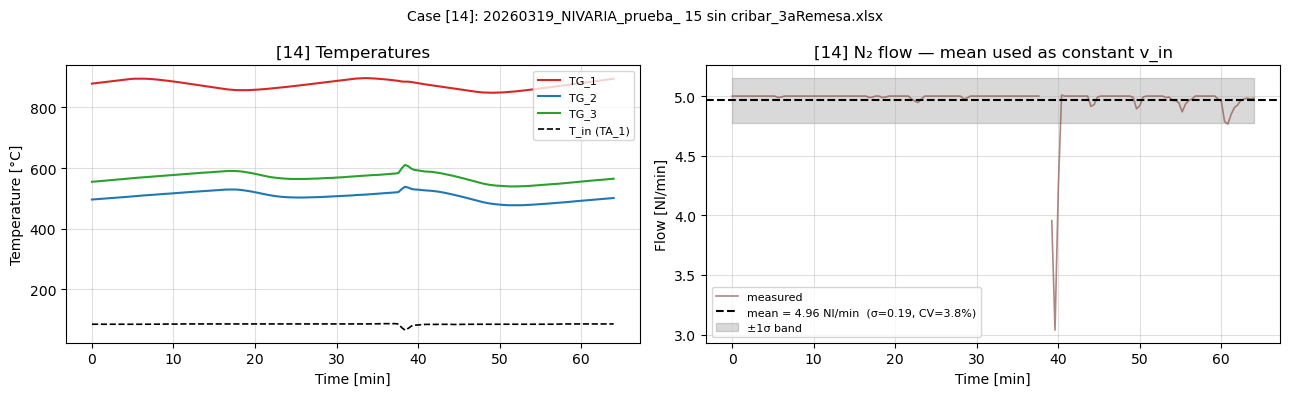

In [7]:
tg_keys = ["TG_1", "TG_2", "TG_3"]
clr_exp = ["#d62728", "#1f77b4", "#2ca02c"]

for idx in VAL_INDICES:
    case = cases_seg[idx]
    df      = case["dfs"].get(SEGMENT_KEY)
    df_flow = case["dfs"].get(FLOW_SEGMENT_KEY)

    if df is None or len(df) == 0:
        print(f"[{idx}] segment '{SEGMENT_KEY}' not found or empty.")
        continue

    t_min      = df["x_min"].values
    t_min_flow = df_flow["x_min"].values if df_flow is not None and len(df_flow) > 0 else None

    fig, axes = plt.subplots(1, 2, figsize=(13, 4))

    ax = axes[0]
    for i, (lbl, col) in enumerate(T_WALL_COLS.items()):
        T = pd.to_numeric(df[col], errors="coerce").values
        ax.plot(t_min, T, color=clr_exp[i], lw=1.5, label=lbl)
    if T_IN_COL in df.columns:
        T_in = pd.to_numeric(df[T_IN_COL], errors="coerce").values
        ax.plot(t_min, T_in, color="k", lw=1.2, ls="--", label="T_in (TA_1)")
    ax.set_xlabel("Time [min]"); ax.set_ylabel("Temperature [°C]")
    ax.set_title(f"[{idx}] Temperatures"); ax.grid(True, alpha=0.4); ax.legend(fontsize=8)

    ax = axes[1]
    if t_min_flow is not None and FLOW_COL in df_flow.columns:
        Q = pd.to_numeric(df_flow[FLOW_COL], errors="coerce").values
        finite = Q[np.isfinite(Q)]
        Q_mean = float(np.mean(finite))
        Q_std  = float(np.std(finite))
        ax.plot(t_min_flow, Q, color="#8c564b", lw=1.2, alpha=0.7, label="measured")
        ax.axhline(Q_mean, color="k", ls="--", lw=1.5,
                   label=f"mean = {Q_mean:.2f} {FLOW_UNIT}  (σ={Q_std:.2f}, CV={Q_std/max(Q_mean,1e-9)*100:.1f}%)")
        ax.fill_between(t_min_flow, Q_mean - Q_std, Q_mean + Q_std,
                        alpha=0.15, color="k", label="±1σ band")
        ax.set_ylabel(f"Flow [{FLOW_UNIT}]")
        ax.legend(fontsize=8)
    else:
        ax.text(0.5, 0.5,
                f"Column '{FLOW_COL}' not found\nin segment '{FLOW_SEGMENT_KEY}'",
                ha="center", va="center", transform=ax.transAxes)
    ax.set_xlabel("Time [min]"); ax.set_title(f"[{idx}] N₂ flow — mean used as constant v_in")
    ax.grid(True, alpha=0.4)

    fig.suptitle(f"Case [{idx}]: {case['file_name']}", fontsize=10)
    plt.tight_layout(); plt.show()

## 8. Validation simulations

Run each validation case with both power sets.

In [8]:
results = {}   # results[idx][power_set_name] = dict

for idx in VAL_INDICES:
    case = cases_seg[idx]
    results[idx] = {}

    for ps_name, ps in POWER_SETS.items():
        print(f"[{idx}] {case['file_name']}  |  {ps_name}")

        t_exp_s, T_exp_K, T_in_K, v_in, t_sim, h, cpu_s = simulate_n2flow(
            case, ps["Q_b"], ps["Q_m"], ps["Q_t"]
        )

        metrics = {}
        for i, key in enumerate(tg_keys):
            Tw_sim_i  = np.interp(t_exp_s, t_sim, h._Tw_results[:, i])
            Tg_sim_i  = np.interp(t_exp_s, t_sim, h._Tg_results[:, i])
            T_exp_i   = T_exp_K[key]
            valid     = np.isfinite(T_exp_i)

            err_w = Tw_sim_i[valid] - T_exp_i[valid]
            err_g = Tg_sim_i[valid] - T_exp_i[valid]

            # Check if probe is inside [Tg, Tw] band
            in_band = np.mean(
                (T_exp_i[valid] >= np.minimum(Tg_sim_i[valid], Tw_sim_i[valid])) &
                (T_exp_i[valid] <= np.maximum(Tg_sim_i[valid], Tw_sim_i[valid]))
            )

            metrics[key] = {
                "rmse_wall": float(np.sqrt(np.mean(err_w**2))),
                "bias_wall": float(np.mean(err_w)),
                "rmse_gas":  float(np.sqrt(np.mean(err_g**2))),
                "bias_gas":  float(np.mean(err_g)),
                "in_band_frac": float(in_band),
            }
            print(f"  {key}: RMSE_wall={metrics[key]['rmse_wall']:.1f} K  "
                  f"RMSE_gas={metrics[key]['rmse_gas']:.1f} K  "
                  f"in_band={metrics[key]['in_band_frac']*100:.0f}%")

        rmse_wall_mean = float(np.mean([m["rmse_wall"] for m in metrics.values()]))
        rmse_gas_mean  = float(np.mean([m["rmse_gas"]  for m in metrics.values()]))
        print(f"  RMSE mean → wall: {rmse_wall_mean:.1f} K  gas: {rmse_gas_mean:.1f} K  |  CPU: {cpu_s:.1f} s")
        print()

        results[idx][ps_name] = {
            "t_exp_s": t_exp_s, "T_exp_K": T_exp_K,
            "t_sim": t_sim, "h": h,
            "v_in": v_in, "metrics": metrics,
            "rmse_wall_mean": rmse_wall_mean,
            "rmse_gas_mean":  rmse_gas_mean,
        }

print("All simulations complete.")

[8] 20260212_NIVARIA_prueba_ 15 cribado.xlsx  |  Set A (case 2)
  Flow: mean=6.79 ± 0.62 Nl/min  →  v_in=2.726 cm/s  (CV=9.2 %)
  T_in mean: 330.7 K (57.5 °C)
  Tw_init [K]: [285.7 286.2 286.2]
  TG_1: RMSE_wall=55.5 K  RMSE_gas=115.5 K  in_band=27%
  TG_2: RMSE_wall=36.6 K  RMSE_gas=49.3 K  in_band=58%
  TG_3: RMSE_wall=42.0 K  RMSE_gas=29.9 K  in_band=37%
  RMSE mean → wall: 44.7 K  gas: 64.9 K  |  CPU: 245.0 s

[8] 20260212_NIVARIA_prueba_ 15 cribado.xlsx  |  Set B (case 3)
  Flow: mean=6.79 ± 0.62 Nl/min  →  v_in=2.726 cm/s  (CV=9.2 %)
  T_in mean: 330.7 K (57.5 °C)
  Tw_init [K]: [285.7 286.2 286.2]
  TG_1: RMSE_wall=61.6 K  RMSE_gas=108.3 K  in_band=35%
  TG_2: RMSE_wall=203.6 K  RMSE_gas=280.3 K  in_band=0%
  TG_3: RMSE_wall=120.4 K  RMSE_gas=249.4 K  in_band=5%
  RMSE mean → wall: 128.5 K  gas: 212.7 K  |  CPU: 297.1 s

[13] 20260317_NIVARIA_prueba_ 20 sin cribar_3aRemesa.xlsx  |  Set A (case 2)
  Flow: mean=5.16 ± 0.64 Nl/min  →  v_in=2.025 cm/s  (CV=12.3 %)
  T_in mean: 323.4

## 9. Results — temperature profiles and errors

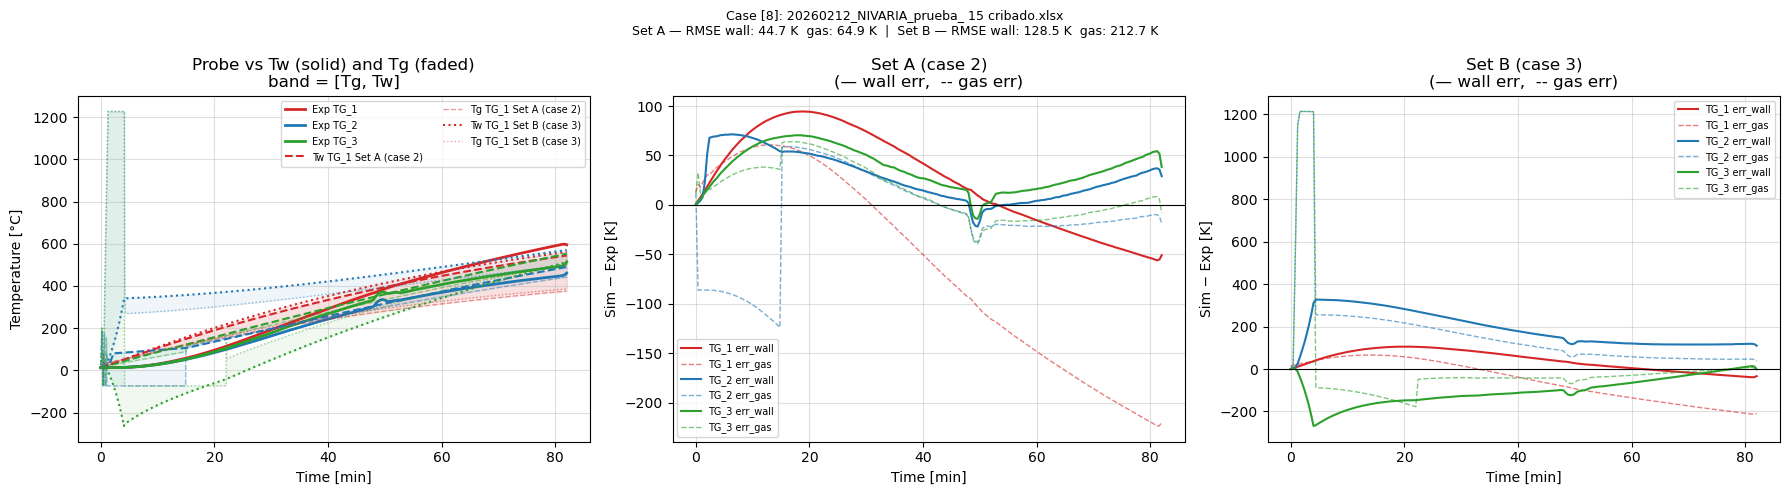

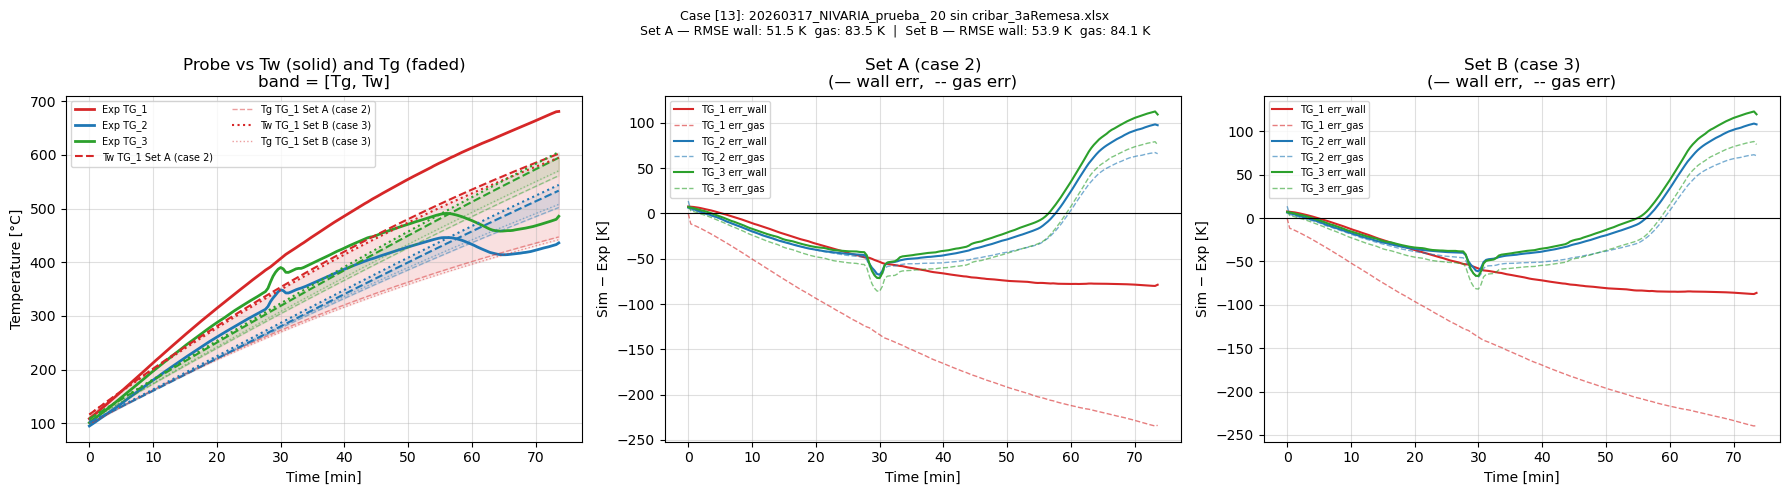

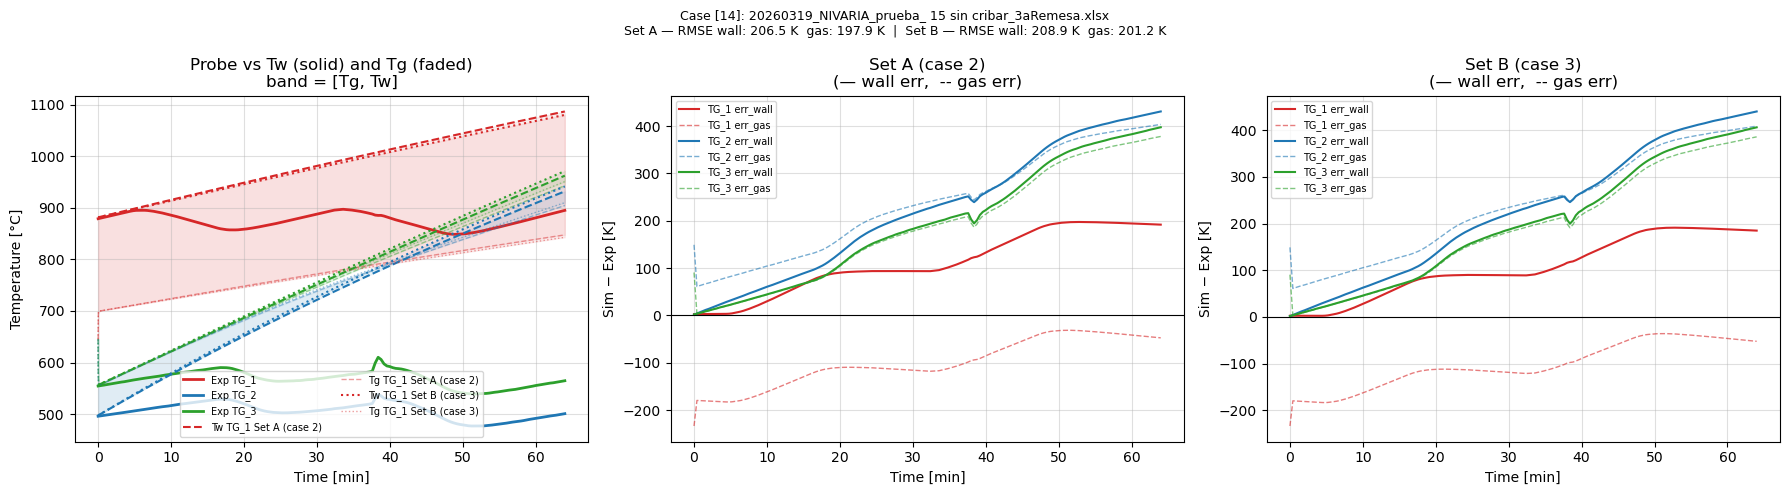

In [9]:
ls_sets = {"Set A (case 2)": "--", "Set B (case 3)": ":"}

# Color per zone: bottom=red, middle=blue, top=green
clr_zone = ["#d62728", "#1f77b4", "#2ca02c"]

for idx in VAL_INDICES:
    case = cases_seg[idx]
    t_exp_s = results[idx][list(POWER_SETS.keys())[0]]["t_exp_s"]
    T_exp_K = results[idx][list(POWER_SETS.keys())[0]]["T_exp_K"]
    t_min   = t_exp_s / 60.0

    n_sets = len(POWER_SETS)
    fig, axes = plt.subplots(1, 1 + n_sets, figsize=(6 + 6 * n_sets, 5))

    # ── Left panel: temperature profiles ─────────────────────────────────────
    ax = axes[0]
    for i, key in enumerate(tg_keys):
        ax.plot(t_min, T_exp_K[key] - 273.15,
                color=clr_zone[i], lw=2.0, label=f"Exp {key}")

    for j, (ps_name, ls) in enumerate(ls_sets.items()):
        r = results[idx][ps_name]
        t_s_m = r["t_sim"] / 60.0
        for i, key in enumerate(tg_keys):
            Tw_i = r["h"]._Tw_results[:, i] - 273.15
            Tg_i = r["h"]._Tg_results[:, i] - 273.15
            # Wall curve
            ax.plot(t_s_m, Tw_i, color=clr_zone[i], lw=1.5, ls=ls,
                    label=f"Tw {key} {ps_name}" if i == 0 else "_")
            # Gas curve (lighter shade)
            ax.plot(t_s_m, Tg_i, color=clr_zone[i], lw=1.0, ls=ls, alpha=0.45,
                    label=f"Tg {key} {ps_name}" if i == 0 else "_")
            # Band between Tg and Tw
            ax.fill_between(t_s_m, Tg_i, Tw_i,
                            color=clr_zone[i], alpha=0.07)

    ax.set_xlabel("Time [min]")
    ax.set_ylabel("Temperature [°C]")
    ax.set_title("Probe vs Tw (solid) and Tg (faded)\nband = [Tg, Tw]")
    ax.grid(True, alpha=0.4)
    ax.legend(fontsize=7, ncol=2)

    # ── One error panel per power set ─────────────────────────────────────────
    for j, (ps_name, ls) in enumerate(ls_sets.items()):
        ax = axes[1 + j]
        r  = results[idx][ps_name]
        t_s_m = r["t_sim"] / 60.0

        for i, key in enumerate(tg_keys):
            Tw_interp = np.interp(t_exp_s, r["t_sim"], r["h"]._Tw_results[:, i])
            Tg_interp = np.interp(t_exp_s, r["t_sim"], r["h"]._Tg_results[:, i])
            T_exp_i   = T_exp_K[key]
            valid     = np.isfinite(T_exp_i)

            ax.plot(t_min[valid], (Tw_interp[valid] - T_exp_i[valid]),
                    color=clr_zone[i], lw=1.5, ls="-",
                    label=f"{key} err_wall")
            ax.plot(t_min[valid], (Tg_interp[valid] - T_exp_i[valid]),
                    color=clr_zone[i], lw=1.0, ls="--", alpha=0.6,
                    label=f"{key} err_gas")

        ax.axhline(0, color="k", lw=0.8)
        ax.set_xlabel("Time [min]")
        ax.set_ylabel("Sim − Exp [K]")
        ax.set_title(f"{ps_name}\n(— wall err,  -- gas err)")
        ax.grid(True, alpha=0.4)
        ax.legend(fontsize=7)

    rA = results[idx]["Set A (case 2)"]
    rB = results[idx]["Set B (case 3)"]
    fig.suptitle(
        f"Case [{idx}]: {case['file_name']}\n"
        f"Set A — RMSE wall: {rA['rmse_wall_mean']:.1f} K  gas: {rA['rmse_gas_mean']:.1f} K  |  "
        f"Set B — RMSE wall: {rB['rmse_wall_mean']:.1f} K  gas: {rB['rmse_gas_mean']:.1f} K",
        fontsize=9,
    )
    plt.tight_layout()
    plt.show()

## 10. Summary

In [10]:
print("=" * 96)
print("  STEP-3 VALIDATION SUMMARY — N2-FLOW CASES (EMPTY COLUMN)")
print("=" * 96)
print()
hdr = (f"  {'Case':>6}  {'Power set':22s}  {'v_in cm/s':>9}"
       f"  {'RMSE_w_TG1':>10}  {'RMSE_w_TG2':>10}  {'RMSE_w_TG3':>10}"
       f"  {'RMSE_g_TG1':>10}  {'RMSE_g_TG2':>10}  {'RMSE_g_TG3':>10}"
       f"  {'in_band%':>8}")
print(hdr)
print("  " + "-" * (len(hdr) - 2))

for idx in VAL_INDICES:
    for ps_name in POWER_SETS:
        r = results[idx][ps_name]
        m = r["metrics"]
        ib_mean = np.mean([m[k]["in_band_frac"] for k in tg_keys]) * 100
        print(
            f"  [{idx:>4}]  {ps_name:22s}  {r['v_in']*100:>9.3f}"
            f"  {m['TG_1']['rmse_wall']:>10.1f}"
            f"  {m['TG_2']['rmse_wall']:>10.1f}"
            f"  {m['TG_3']['rmse_wall']:>10.1f}"
            f"  {m['TG_1']['rmse_gas']:>10.1f}"
            f"  {m['TG_2']['rmse_gas']:>10.1f}"
            f"  {m['TG_3']['rmse_gas']:>10.1f}"
            f"  {ib_mean:>7.0f}%"
        )
    print()

print("=" * 96)
print()
print("  Notes:")
print("  • RMSE_w = error vs wall temperature (Tw_sim).  RMSE_g = error vs gas temperature (Tg_sim).")
print("  • With N2 flow the probe reads between Tg and Tw: both metrics bracket the true error.")
print("  • in_band% = fraction of time the probe reading lies inside [Tg_sim, Tw_sim].")
print("  • in_band% ≈ 100% → model is physically consistent with probe location.")
print("  • RMSE_w < 15 K or RMSE_g < 15 K → power set transfers well to N2-flow regime.")

  STEP-3 VALIDATION SUMMARY — N2-FLOW CASES (EMPTY COLUMN)

    Case  Power set               v_in cm/s  RMSE_w_TG1  RMSE_w_TG2  RMSE_w_TG3  RMSE_g_TG1  RMSE_g_TG2  RMSE_g_TG3  in_band%
  ---------------------------------------------------------------------------------------------------------------------------
  [   8]  Set A (case 2)              2.726        55.5        36.6        42.0       115.5        49.3        29.9       41%
  [   8]  Set B (case 3)              2.726        61.6       203.6       120.4       108.3       280.3       249.4       14%

  [  13]  Set A (case 2)              2.025        58.6        46.7        49.4       157.7        43.3        49.5        6%
  [  13]  Set B (case 3)              2.025        63.8        47.0        50.9       161.4        42.5        48.6        6%

  [  14]  Set A (case 2)              2.153       129.0       259.2       231.2       111.7       259.9       222.1       33%
  [  14]  Set B (case 3)              2.153       124.6 